In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from faker import Faker

fake = Faker('ar_AA') 
arabic_names = []
for _ in range(50000):
    arabic_names.append(fake.first_name())

with open('arabic_names.txt', 'w', encoding='utf-8') as f:
    for name in arabic_names:
        f.write(name + '\n')
        
print("Generated 50,000 single first names!")

Generated 50,000 single first names!


In [3]:
names = open('./arabic_names.txt', 'r', encoding='utf-8').read().splitlines()

In [4]:
chars = sorted(list(set(''.join(names))))
chars

[' ',
 'ء',
 'آ',
 'أ',
 'ؤ',
 'إ',
 'ئ',
 'ا',
 'ب',
 'ة',
 'ت',
 'ث',
 'ج',
 'ح',
 'خ',
 'د',
 'ذ',
 'ر',
 'ز',
 'س',
 'ش',
 'ص',
 'ض',
 'ط',
 'ظ',
 'ع',
 'غ',
 'ف',
 'ق',
 'ك',
 'ل',
 'م',
 'ن',
 'ه',
 'و',
 'ى',
 'ي',
 'َ',
 'ُ',
 'ّ']

In [5]:
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
stoi

{' ': 1,
 'ء': 2,
 'آ': 3,
 'أ': 4,
 'ؤ': 5,
 'إ': 6,
 'ئ': 7,
 'ا': 8,
 'ب': 9,
 'ة': 10,
 'ت': 11,
 'ث': 12,
 'ج': 13,
 'ح': 14,
 'خ': 15,
 'د': 16,
 'ذ': 17,
 'ر': 18,
 'ز': 19,
 'س': 20,
 'ش': 21,
 'ص': 22,
 'ض': 23,
 'ط': 24,
 'ظ': 25,
 'ع': 26,
 'غ': 27,
 'ف': 28,
 'ق': 29,
 'ك': 30,
 'ل': 31,
 'م': 32,
 'ن': 33,
 'ه': 34,
 'و': 35,
 'ى': 36,
 'ي': 37,
 'َ': 38,
 'ُ': 39,
 'ّ': 40,
 '.': 0}

In [6]:
N = torch.zeros((41, 41), dtype=torch.int32)

In [7]:
for name in names:
    chrs = ['.'] + list(name) + ['.']
    for char1, char2 in zip(chrs, chrs[1:]):
        i1 = stoi[char1]
        i2 = stoi[char2]
        N[i1, i2] += 1

In [8]:
itos = {i:s for s,i in stoi.items()}

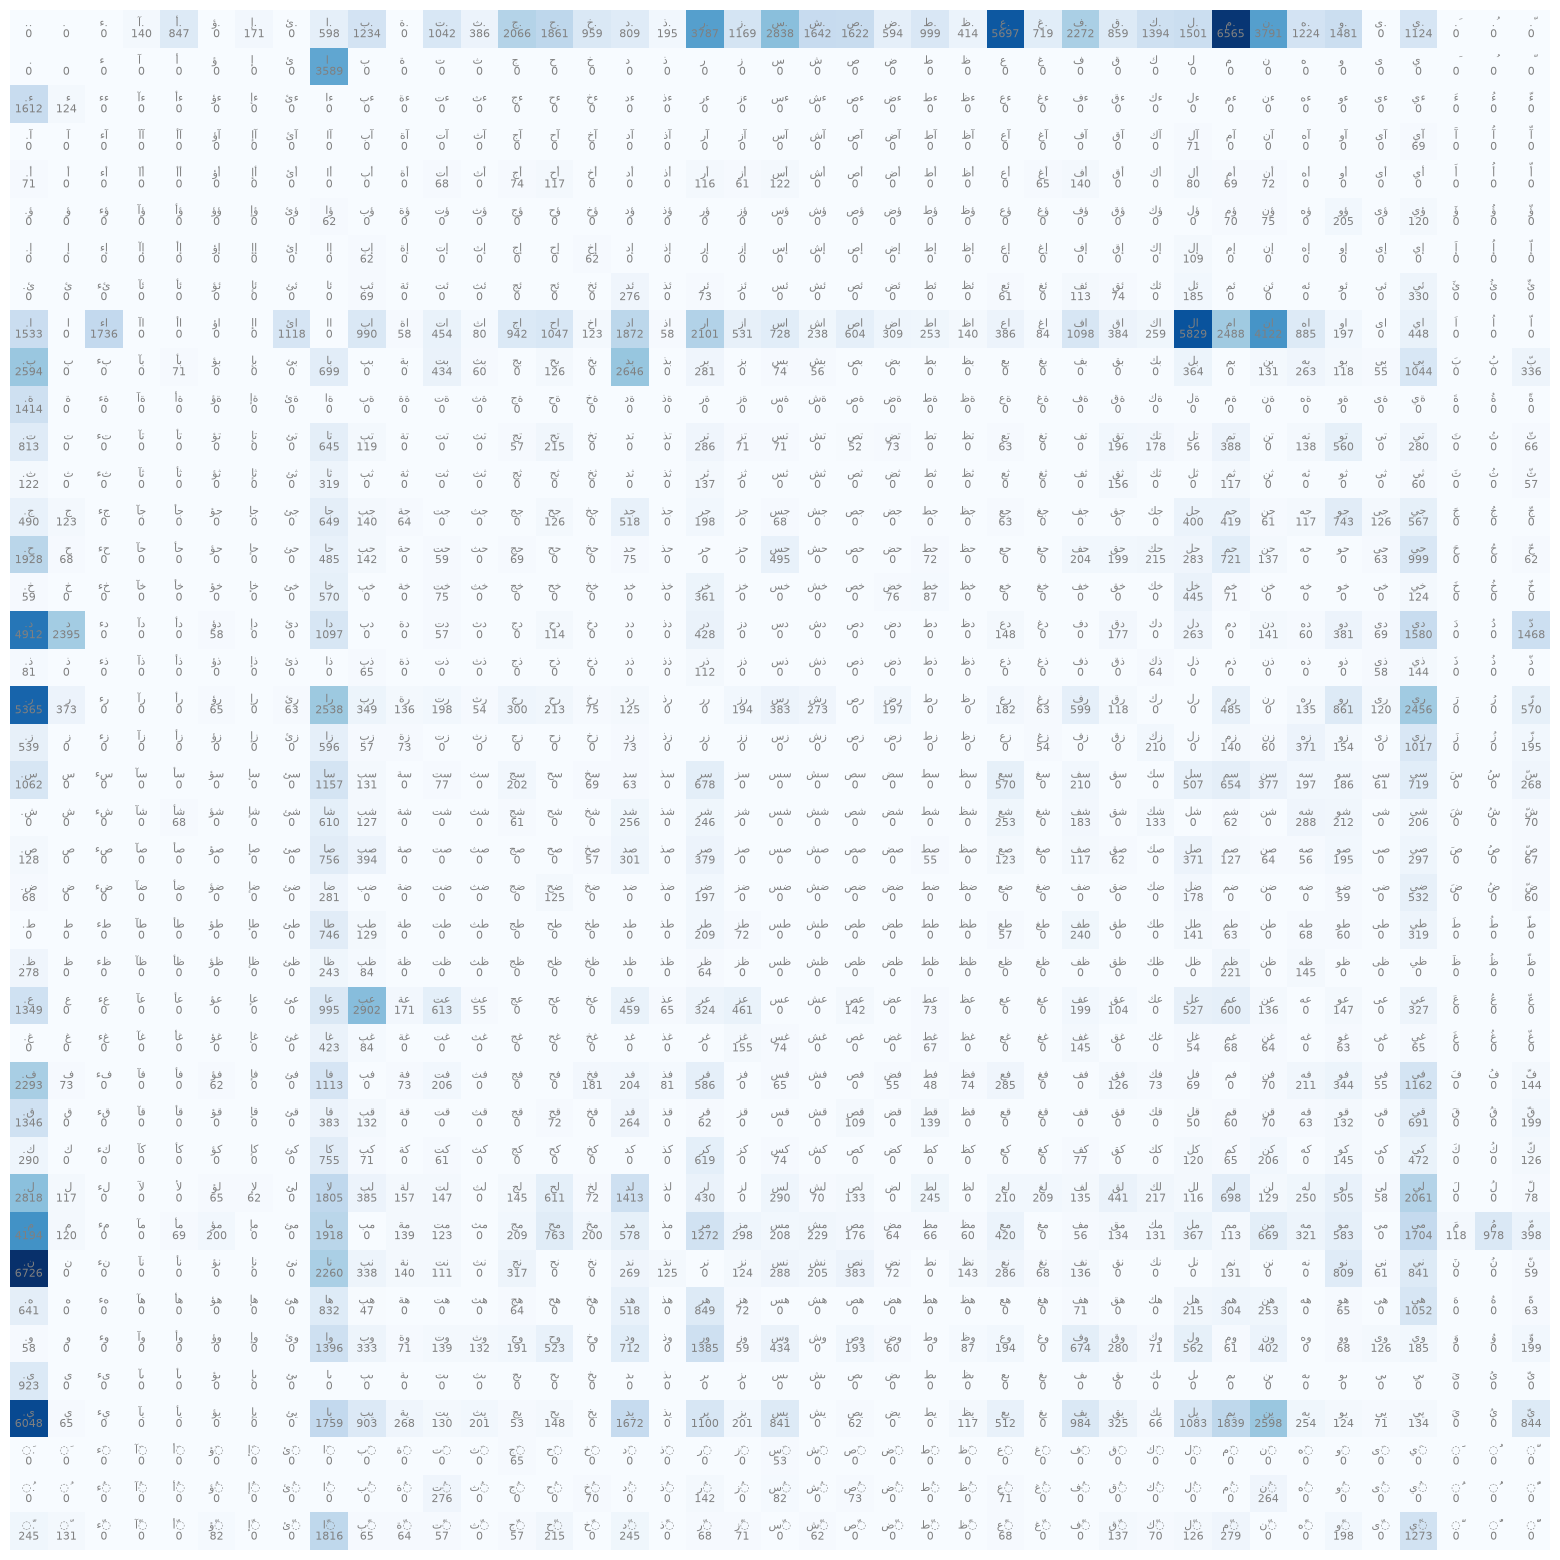

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(20, 20))
plt.imshow(N, cmap='Blues')

for i in range(41):
    for j in range(41):
        chstr = itos[i] + itos[j]

        plt.text(j, i, chstr,
                 ha="center", va="bottom", color="gray", fontsize=8)

        plt.text(j, i, N[i, j].item(),
                 ha="center", va="top", color="gray", fontsize=8)

plt.axis('off');

In [10]:
N[0]

tensor([   0,    0,    0,  140,  847,    0,  171,    0,  598, 1234,    0, 1042,
         386, 2066, 1861,  959,  809,  195, 3787, 1169, 2838, 1642, 1622,  594,
         999,  414, 5697,  719, 2272,  859, 1394, 1501, 6565, 3791, 1224, 1481,
           0, 1124,    0,    0,    0], dtype=torch.int32)

In [11]:
p = N.float()
p = p/p.sum(1, keepdim=True)

In [12]:
g = torch.Generator().manual_seed(2147483647)
for i in range(5):
    out = []
    ix = 0
    while True:
        P = p[ix]
        ix = torch.multinomial(P, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

ميادّرولحماهد.
جالل.
حي.
كا.
ما.


In [13]:
log_likelihood = 0.0
n = 0

for w in names[:3]:
    chrs = ['.'] + list(w) + ['.']
    for char1, char2 in zip(chrs, chrs[1:]):
        ix1 = stoi[char1]
        ix2 = stoi[char2]
        prob = p[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        print(f'{char1}{char2}: {logprob:.4f}')
print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

.ر: -2.5804
رئ: -5.5674
ئي: -1.2750
يس: -3.2823
س.: -1.9123
.ك: -3.5798
كر: -1.6049
ري: -1.9042
يم: -2.4999
م.: -1.3924
.ر: -2.5804
را: -1.8714
ائ: -3.3255
ئف: -2.3467
ف.: -1.2052
log_likelihood=tensor(-36.9280)
nll=tensor(36.9280)
2.461864948272705


In [ ]:
xs , ys = [], []
for w in names:
    chrs = ['.'] + list(w) + ['.']
    for char1, char2 in zip(chrs, chrs[1:]):
        ix1 = stoi[char1]
        ix2 = stoi[char2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [72]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=41).float()
xenc.shape
W = torch.randn((41, 41), generator=g, requires_grad=True)


In [84]:
logits = xenc @ W
counts = logits.exp()
probs = counts/counts.sum(1, keepdim=True)
loss = -probs[torch.arange(ys.shape[0]), ys].log().mean()

In [85]:
W.grad = None
loss.backward()
W.data += 0.1 * W.grad

In [86]:
loss

tensor(4.2108, grad_fn=<NegBackward0>)

In [92]:
xs , ys = [], []
for w in names:
    chrs = ['.'] + list(w) + ['.']
    for char1, char2 in zip(chrs, chrs[1:]):
        ix1 = stoi[char1]
        ix2 = stoi[char2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print(num)
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((41, 41), generator=g, requires_grad=True)

284340


In [96]:
for k in range(100):
    xenc = F.one_hot(xs, num_classes=41).float()
    logits = xenc @ W
    counts = logits.exp()
    probs = counts/counts.sum(1, keepdim=True)
    loss = -probs[torch.arange(ys.shape[0]), ys].log().mean()
    print(loss.item())

    W.grad = None
    loss.backward()

    W.data += -50 * W.grad

2.5614678859710693
2.560807943344116
2.5601589679718018
2.559520721435547
2.5588929653167725
2.5582752227783203
2.5576674938201904
2.557069778442383
2.556480884552002
2.555901527404785
2.555331230163574
2.554769515991211
2.5542166233062744
2.5536720752716064
2.553135633468628
2.5526070594787598
2.55208683013916
2.5515739917755127
2.5510685443878174
2.550570487976074
2.550079345703125
2.549595594406128
2.5491185188293457
2.5486481189727783
2.548184394836426
2.54772686958313
2.547276258468628
2.546830892562866
2.5463922023773193
2.545959234237671
2.545531988143921
2.5451107025146484
2.544694662094116
2.5442841053009033
2.543879270553589
2.5434794425964355
2.5430846214294434
2.5426948070526123
2.5423102378845215
2.5419304370880127
2.541555166244507
2.541184902191162
2.5408191680908203
2.5404579639434814
2.5401012897491455
2.5397486686706543
2.539400339126587
2.5390565395355225
2.5387165546417236
2.5383806228637695
2.53804874420166
2.5377206802368164
2.5373969078063965
2.537076711654663
2.